In [1]:
import pandas as pd 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score 
import xgboost as xgb

Link to dataset: https://www.kaggle.com/datasets/bittupanchal/breast-cancer-detection-dataset

In [2]:
df = pd.read_excel("df.xlsx")
df

,id,diagnosis,Radius_mean,Texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,21.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   Radius_mean              569 non-null    float64
 3   Texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

Distribution of tumor types in the dataset: 

c:\Users\Anvita\miniconda3\envs\env\Lib\site-packages\seaborn\axisgrid.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(**kwargs)


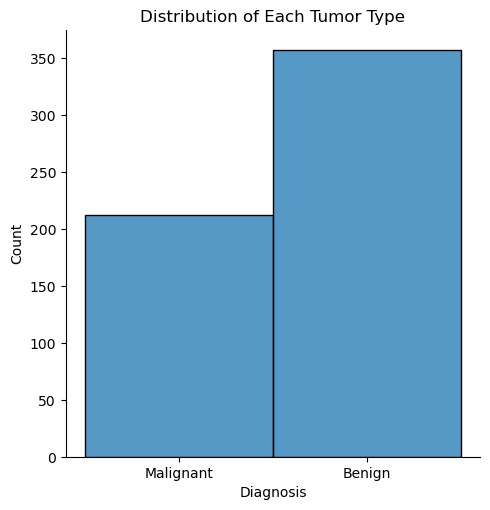

In [4]:
plot = sns.displot(data = df, x = "diagnosis")
plot.set(title = "Distribution of Each Tumor Type", xlabel = "Diagnosis", 
         xticklabels = ["Malignant", "Benign"])

Dataset contains more benign tumor data than it does malignant tumor data. 

The next set of plots are meant to compare distributions of certain features between the types of tumors. 

c:\Users\Anvita\miniconda3\envs\env\Lib\site-packages\seaborn\axisgrid.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(**kwargs)


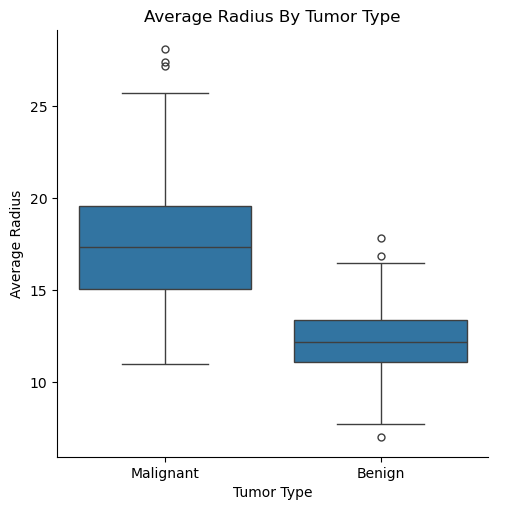

In [5]:
plot = sns.catplot(data = df, x = "diagnosis", y = "Radius_mean", kind = "box")
plot.set(title = "Average Radius By Tumor Type", xlabel = "Tumor Type", ylabel = "Average Radius", 
         xticklabels= ['Malignant', 'Benign'])


[Text(0.5, 1.0, 'Distribution of Symmetry among Tumor Types'),
 Text(0.5, 0, 'Average Symmetry')]

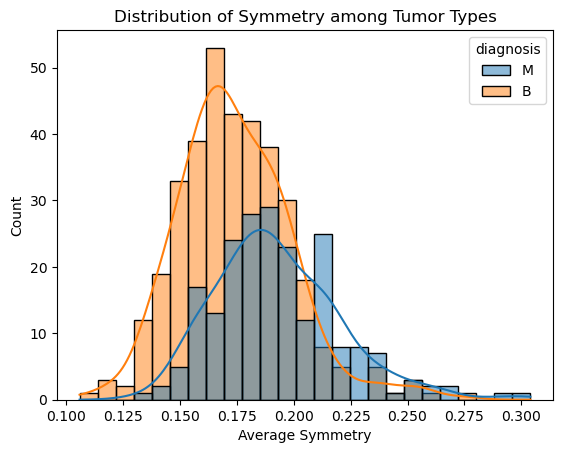

In [6]:
plot = sns.histplot(data = df, x = 'symmetry_mean', hue = 'diagnosis', kde = True)
plot.set(title = "Distribution of Symmetry among Tumor Types", xlabel = "Average Symmetry")

[Text(0.5, 1.0, 'Distribution of Average Tumor Perimeter'),
 Text(0.5, 0, 'Average Perimeter')]

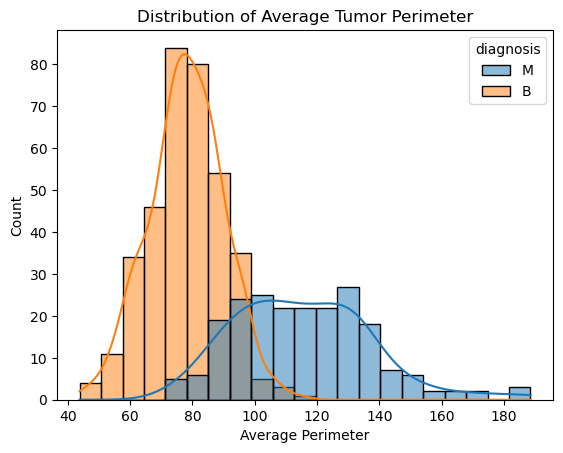

In [7]:
plot = sns.histplot(data = df, x = "perimeter_mean", hue = "diagnosis", kde = True)
plot.set(title = "Distribution of Average Tumor Perimeter", xlabel = "Average Perimeter")

Key notes: 
- Malignant tumors seem to have a higher radius compared to benign tumors, suggests that they tend to be bigger
- Malignant tumors have a slightly larger distribution of symmetry measure while benign tumors are more centered around a lower value. It is not clear from the dataset source what this measure is actually describing. 
- Malignant tumors have a larger distribution of perimeter values. Smaller perimeters are more common for a benign tumor. 

Pairwise plot to visually identify clustering and correlation between the average measures:

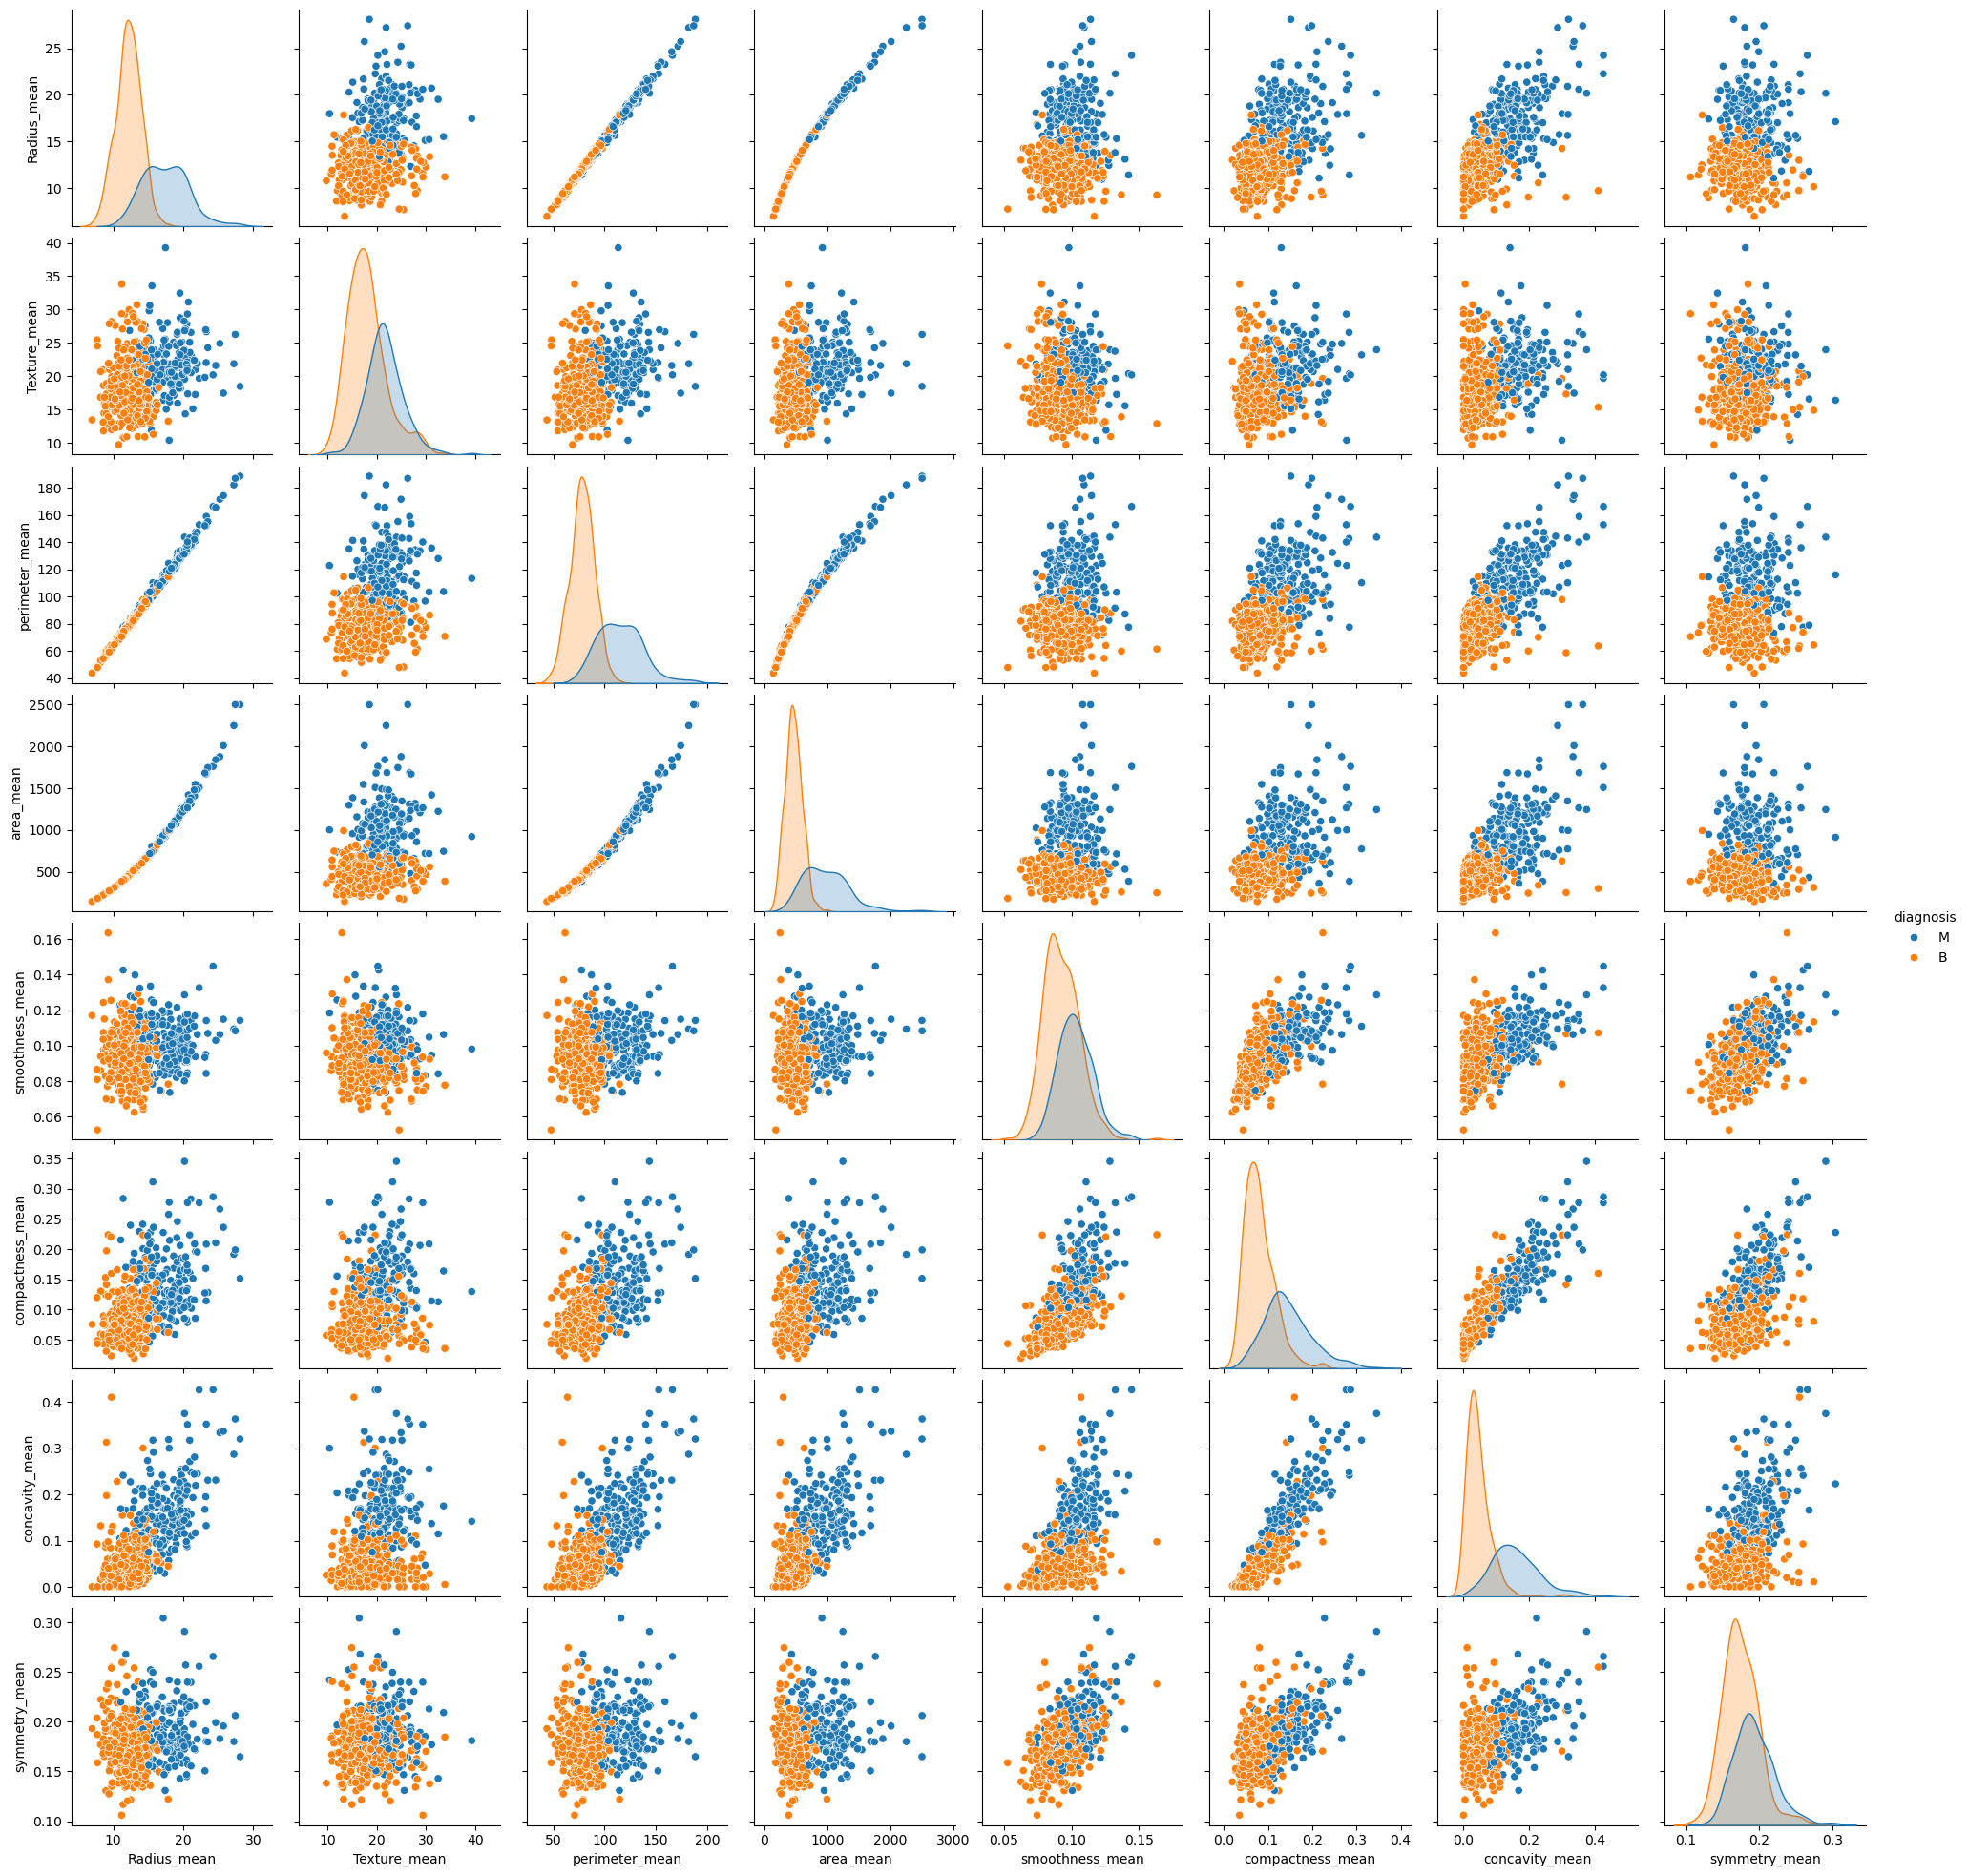

In [8]:
means = ['diagnosis', 'Radius_mean', 'Texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean',
         'concavity_mean', 'symmetry_mean']
sns.pairplot(data = df[means], hue = "diagnosis")

Overall, there seems to be a distinct difference between values for a malignant tumor and values for a benign tumor. Radius, perimeter, and area seem to share the strongest correlation. This makes intuitive sense since these are all measures that impact the value of each other. For example, radius is used in the area calculation & would affect the size or perimeter of the tumor. 

# Classification

Random Forest Classifier: 

In [9]:
diag = LabelEncoder()
df['diagnosis'] = diag.fit_transform(df['diagnosis'])
#1 is malignant, 2 is benign 

In [10]:
y = df['diagnosis']

In [11]:
features = ['Radius_mean', 'Texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 
            'compactness_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_mean']
X = df[features]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7)

In [13]:
model1 = RandomForestClassifier()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
acc = accuracy_score(y_test, y_pred1)
prec = precision_score(y_test, y_pred1)

In [14]:
print("Accuracy Score: {0}\nPrecision Score: {1}".format(acc, prec))

Accuracy Score: 0.935672514619883
Precision Score: 0.9672131147540983


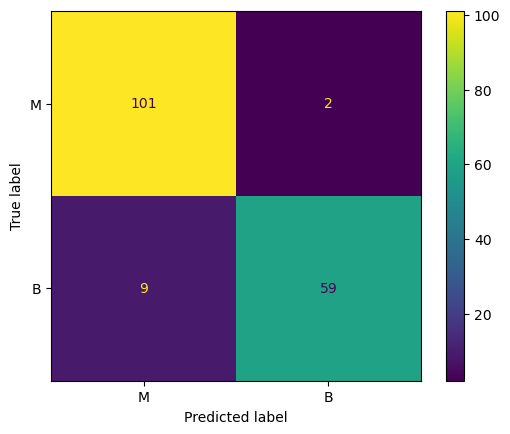

In [15]:
cm = confusion_matrix(y_test, y_pred1)
disp = ConfusionMatrixDisplay(cm, display_labels= ['M', 'B'])
disp.plot()
plt.show()

XGBoost Classifier:

In [16]:
model2 = xgb.XGBClassifier()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
acc = accuracy_score(y_test, y_pred2)
prec = precision_score(y_test, y_pred2)
cm = confusion_matrix(y_test, y_pred2)

Accuracy score: 0.9415204678362573
Precision score: 0.953125


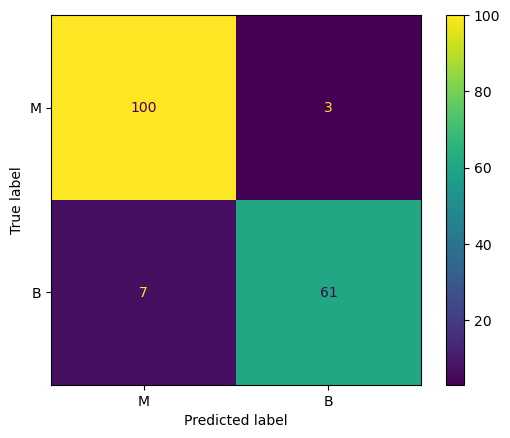

In [17]:
print("Accuracy score: {0}\nPrecision score: {1}".format(acc, prec))
disp = ConfusionMatrixDisplay(cm, display_labels = ['M', 'B'])
disp.plot()
plt.show()

Both Random Forest & XGBoost have similar precision and accuracy scores with the same set of features that were used to create the model. These models seem to be able to predict diagnosis of the tumor accurately. However, this dataset is also on the smaller side with less than 600 observations in total which means more data is needed to properly tune and test both classifiers. 